# Day-Ahead Electricity Demand Forecasting — Austria (2025)

**Dataset:** ENTSO-E Actual Total Load — Austria (AT), January–October 2025  
**Source:** [ENTSO-E Transparency Platform](https://transparency.entsoe.eu/)  
**Target:** Predict Austria's total electricity load 24 hours ahead  
**Models:** ARIMA (classical baseline) · XGBoost · Random Forest · Ensemble

---

## 0. Setup & Imports

In [1]:
# Install any missing packages (run once)
# !pip install pandas numpy matplotlib seaborn statsmodels scikit-learn xgboost holidays

In [2]:
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd

import matplotlib.pyplot  as plt
import matplotlib.dates   as mdates
import seaborn            as sns

from statsmodels.tsa.stattools     import adfuller
from statsmodels.tsa.seasonal      import seasonal_decompose
from statsmodels.tsa.arima.model   import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics      import mean_absolute_error, mean_squared_error
from sklearn.ensemble     import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline     import Pipeline

from xgboost import XGBRegressor
import holidays as hol

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid')
os.makedirs('plots', exist_ok=True)

print('All libraries loaded.')

All libraries loaded.


## 1. Data Loading & Preprocessing

In [3]:
# ── Robust data directory detection ────────────────────────────────────────
import os, pathlib

def _find_data_dir():
    """Search for the data/ folder relative to common Jupyter launch points."""
    candidates = [
        'data',         # launched from energy/ root
        '../data',      # launched from energy/notebooks/
        '../../data',   # deeper nesting
    ]
    for c in candidates:
        p = pathlib.Path(c)
        files = list(p.glob('2025_*_ActualTotalLoad*.csv'))
        if files:
            print(f'✅  Found data directory: {p.resolve()}')
            return str(p)
    # Last resort: ask user
    raise FileNotFoundError(
        "Could not find data/ folder automatically.\n"
        "Please set DATA_DIR manually to the folder containing your CSVs."
    )

DATA_DIR   = _find_data_dir()
load_files = sorted(pathlib.Path(DATA_DIR).glob('2025_*_ActualTotalLoad*.csv'))

print(f'Found {len(load_files)} monthly files:')
for f in load_files:
    print(f'  {f.name}')


✅  Found data directory: /Users/feya/Downloads/energy/data
Found 12 monthly files:
  2025_01_ActualTotalLoad_6.1.A_r3.csv
  2025_02_ActualTotalLoad_6.1.A_r3.csv
  2025_03_ActualTotalLoad_6.1.A_r3.csv
  2025_04_ActualTotalLoad_6.1.A_r3.csv
  2025_05_ActualTotalLoad_6.1.A_r3.csv
  2025_06_ActualTotalLoad_6.1.A_r3.csv
  2025_07_ActualTotalLoad_6.1.A_r3.csv
  2025_08_ActualTotalLoad_6.1.A_r3.csv
  2025_09_ActualTotalLoad_6.1.A_r3.csv
  2025_10_ActualTotalLoad_6.1.A_r3.csv
  2025_11_ActualTotalLoad_6.1.A_r3.csv
  2025_12_ActualTotalLoad_6.1.A_r3.csv


In [4]:
df_raw = pd.concat(
    [pd.read_csv(f, sep='\t') for f in load_files],
    ignore_index=True
)
print(f'Raw shape   : {df_raw.shape}')
print(f'Countries   : {df_raw["AreaMapCode"].nunique()}')
df_raw.head(3)


Raw shape   : (1443747, 8)
Countries   : 62


,DateTime(UTC),ResolutionCode,AreaCode,AreaDisplayName,AreaTypeCode,AreaMapCode,TotalLoad[MW],UpdateTime(UTC)
0,2025-01-01 00:00:00,PT15M,10YAL-KESH-----5,Albania (AL),BZN/CTA/CTY,AL,843.0,2026-02-19 14:40:24
1,2025-01-01 00:15:00,PT15M,10YAL-KESH-----5,Albania (AL),BZN/CTA/CTY,AL,843.0,2026-02-19 14:40:24
2,2025-01-01 00:30:00,PT15M,10YAL-KESH-----5,Albania (AL),BZN/CTA/CTY,AL,843.0,2026-02-19 14:40:24


In [5]:
# Filter to Austria only
df_at = df_raw[df_raw['AreaMapCode'] == 'AT'].copy()
df_at = df_at.rename(columns={'DateTime(UTC)': 'datetime', 'TotalLoad[MW]': 'load'})
df_at['datetime'] = pd.to_datetime(df_at['datetime'])
df_at = df_at[['datetime','load']].sort_values('datetime').reset_index(drop=True)

print(f'Austria shape : {df_at.shape}')
print(f'Date range    : {df_at["datetime"].min()} → {df_at["datetime"].max()}')
print(f'Missing values: {df_at["load"].isna().sum()}')
df_at.head()

Austria shape : (35040, 2)
Date range    : 2025-01-01 00:00:00 → 2025-12-31 23:45:00
Missing values: 0


,datetime,load
0,2025-01-01 00:00:00,6325.6
1,2025-01-01 00:15:00,6272.8
2,2025-01-01 00:30:00,6209.2
3,2025-01-01 00:45:00,6135.2
4,2025-01-01 01:00:00,6180.8


In [6]:
# Resample 15-min → hourly mean, fill short gaps
df_h = df_at.set_index('datetime').resample('1h').mean()
df_h['load'] = df_h['load'].interpolate(method='time', limit=3)

print(f'Hourly shape : {df_h.shape}')
print(f'Remaining NaN: {df_h["load"].isna().sum()}')
df_h.head()

Hourly shape : (8760, 1)
Remaining NaN: 0


,load
datetime,
2025-01-01 00:00:00,6235.7
2025-01-01 01:00:00,6079.6
2025-01-01 02:00:00,5895.7
2025-01-01 03:00:00,5830.5
2025-01-01 04:00:00,5997.9


## 2. Exploratory Data Analysis (EDA)

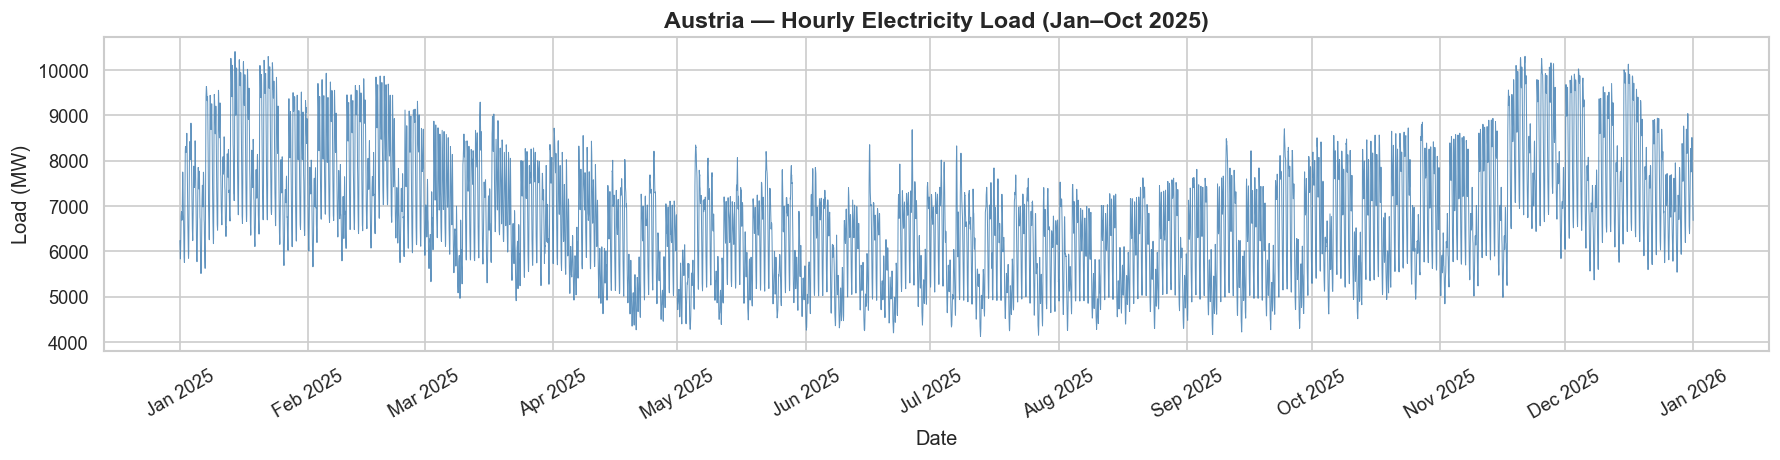

count     8760.0
mean      6762.5
std       1316.5
min       4124.4
25%       5718.8
50%       6710.2
75%       7611.0
max      10401.6
Name: load, dtype: float64


In [7]:
# 2.1 Full time-series
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df_h.index, df_h['load'], color='steelblue', linewidth=0.6, alpha=0.85)
ax.set_title('Austria — Hourly Electricity Load (Jan–Oct 2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Load (MW)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/01_full_series.png', bbox_inches='tight')
plt.show()
print(df_h['load'].describe().round(1))

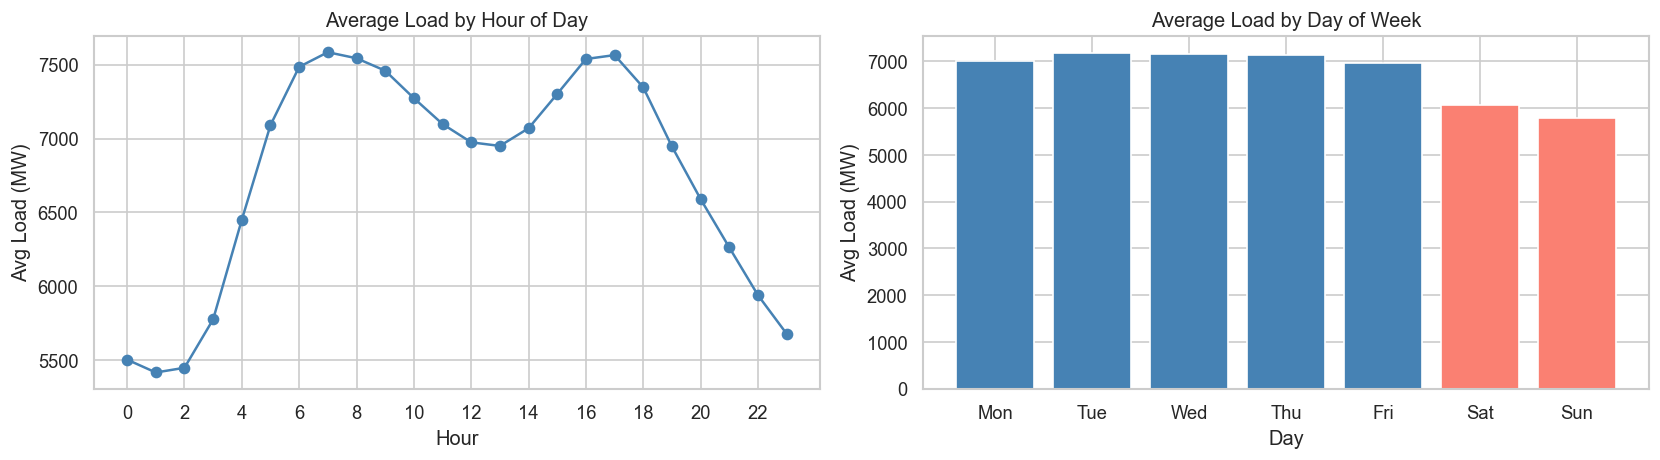

In [8]:
# 2.2 Average load by hour-of-day and day-of-week
df_h['hour']      = df_h.index.hour
df_h['dayofweek'] = df_h.index.dayofweek
df_h['month']     = df_h.index.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hour_avg = df_h.groupby('hour')['load'].mean()
axes[0].plot(hour_avg.index, hour_avg.values, marker='o', color='steelblue')
axes[0].set_title('Average Load by Hour of Day')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Avg Load (MW)')
axes[0].set_xticks(range(0, 24, 2))

dow_avg = df_h.groupby('dayofweek')['load'].mean()
labels  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(labels, dow_avg.values, color=['steelblue']*5 + ['salmon']*2)
axes[1].set_title('Average Load by Day of Week')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Avg Load (MW)')

plt.tight_layout()
plt.savefig('plots/02_daily_weekly_pattern.png', bbox_inches='tight')
plt.show()

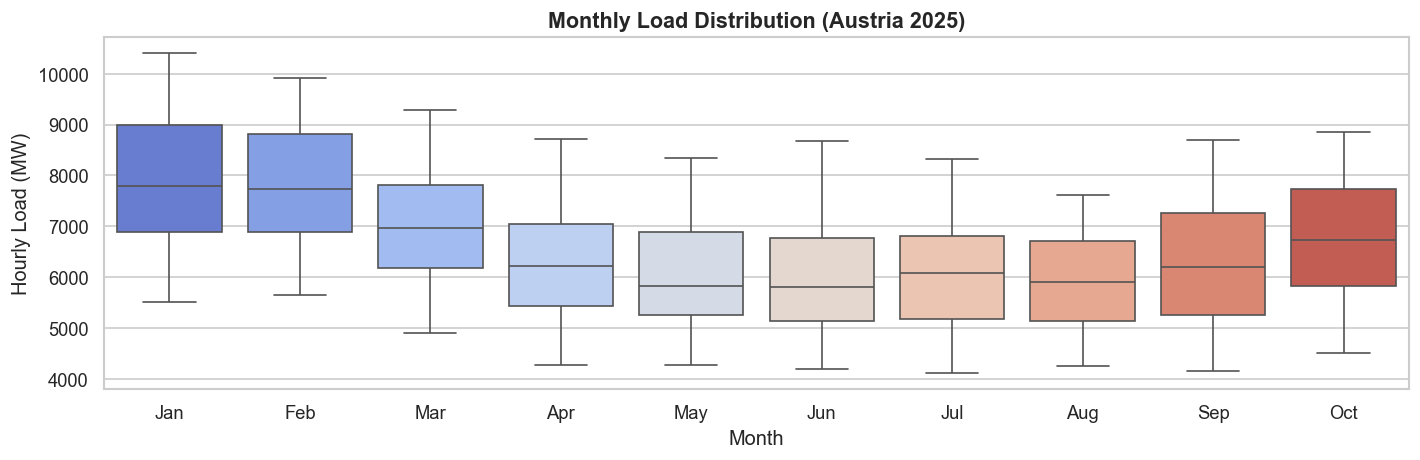

In [9]:
# 2.3 Monthly box plots
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']
df_tmp = df_h.copy()
df_tmp['month_name'] = df_tmp.index.strftime('%b')

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df_tmp, x='month_name', y='load', order=month_labels,
            palette='coolwarm', ax=ax)
ax.set_title('Monthly Load Distribution (Austria 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Hourly Load (MW)')
plt.tight_layout()
plt.savefig('plots/03_monthly_distribution.png', bbox_inches='tight')
plt.show()

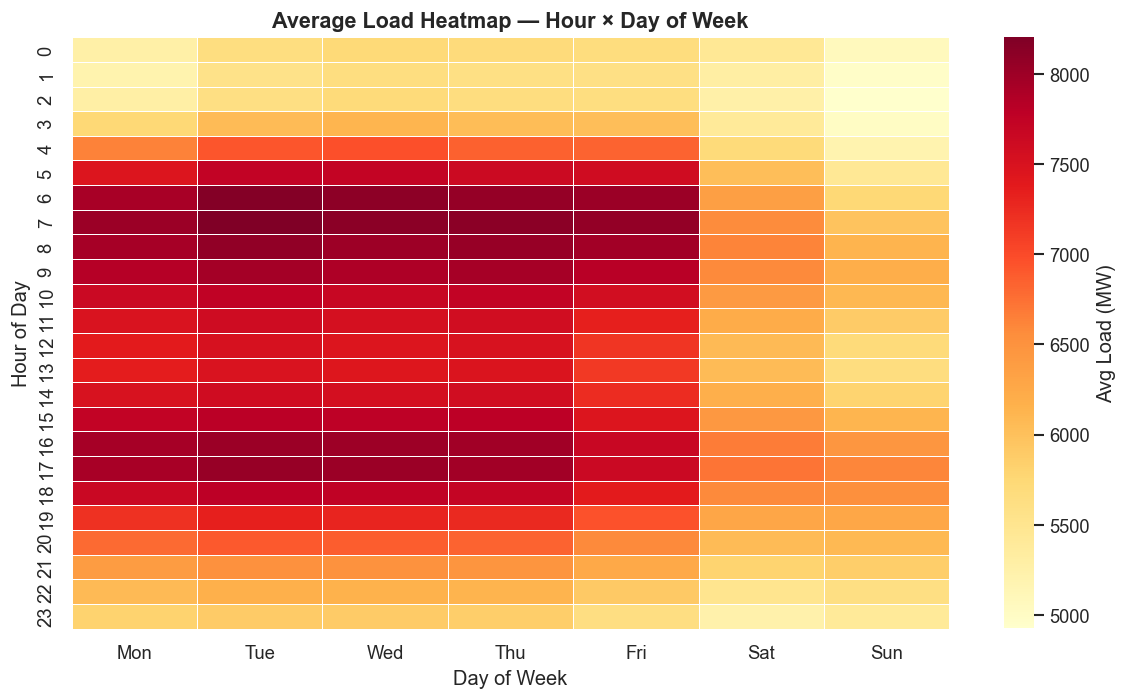

In [10]:
# 2.4 Heatmap: hour × day-of-week
pivot = df_h.pivot_table(values='load', index='hour', columns='dayofweek', aggfunc='mean')
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, annot=False,
            linewidths=0.3, cbar_kws={'label': 'Avg Load (MW)'})
ax.set_title('Average Load Heatmap — Hour × Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.savefig('plots/04_heatmap.png', bbox_inches='tight')
plt.show()

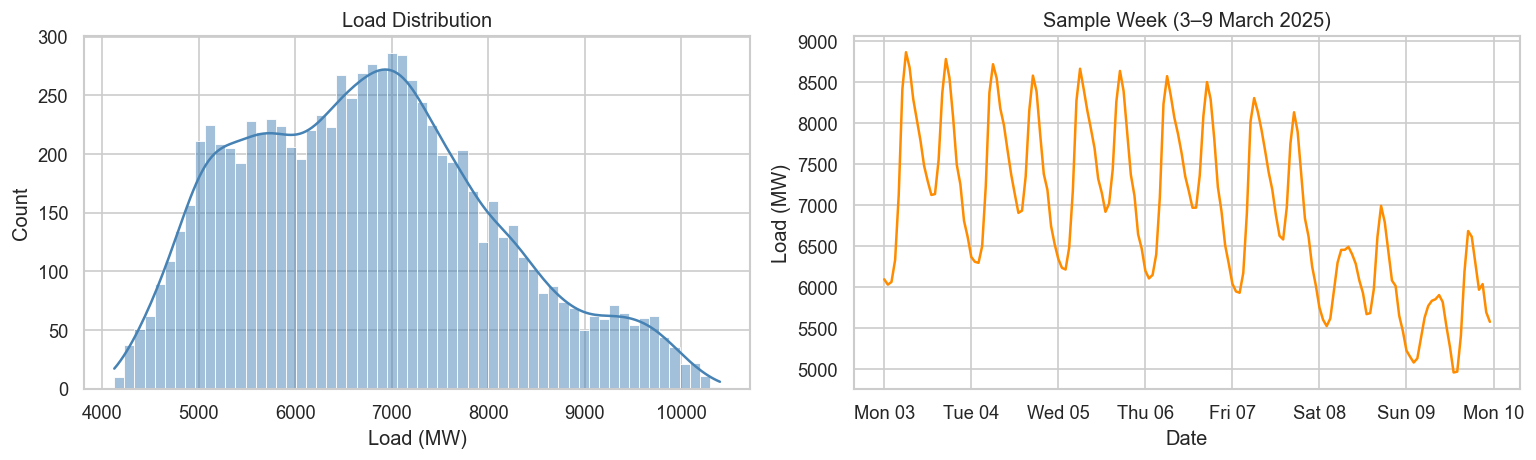

In [11]:
# 2.5 Distribution + sample week
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_h['load'].dropna(), bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Load Distribution'); axes[0].set_xlabel('Load (MW)')

sample = df_h['load']['2025-03-03':'2025-03-09']
axes[1].plot(sample.index, sample.values, color='darkorange', linewidth=1.5)
axes[1].set_title('Sample Week (3–9 March 2025)')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Load (MW)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))

plt.tight_layout()
plt.savefig('plots/05_distribution_sample.png', bbox_inches='tight')
plt.show()

**EDA Key Findings:**
- Clear **daily cycle**: load rises from ~06:00, peaks ~10–11h and again at ~19–20h, drops overnight.
- Strong **weekly seasonality**: weekday demand ~10–15% higher than weekends.
- **Seasonal trend**: Jan/Feb and Oct show higher load than summer months (heating demand).
- Load ranges from ~4,500 MW (overnight summer) to ~11,000 MW (winter peak).

## 3. Time Series Analysis

In [12]:
# 3.1 Augmented Dickey-Fuller Test
series = df_h['load'].dropna()
adf = adfuller(series, autolag='AIC')

print('Augmented Dickey-Fuller Test')
print('=' * 42)
print(f'Test statistic : {adf[0]:.4f}')
print(f'p-value        : {adf[1]:.6f}')
print(f'Lags used      : {adf[2]}')
for k, v in adf[4].items():
    print(f'  Critical ({k}): {v:.4f}')
print()
print('✅ STATIONARY' if adf[1] < 0.05 else '⚠️  NON-STATIONARY')

Augmented Dickey-Fuller Test
Test statistic : -7.5786
p-value        : 0.000000
Lags used      : 37
  Critical (1%): -3.4311
  Critical (5%): -2.8619
  Critical (10%): -2.5669

✅ STATIONARY


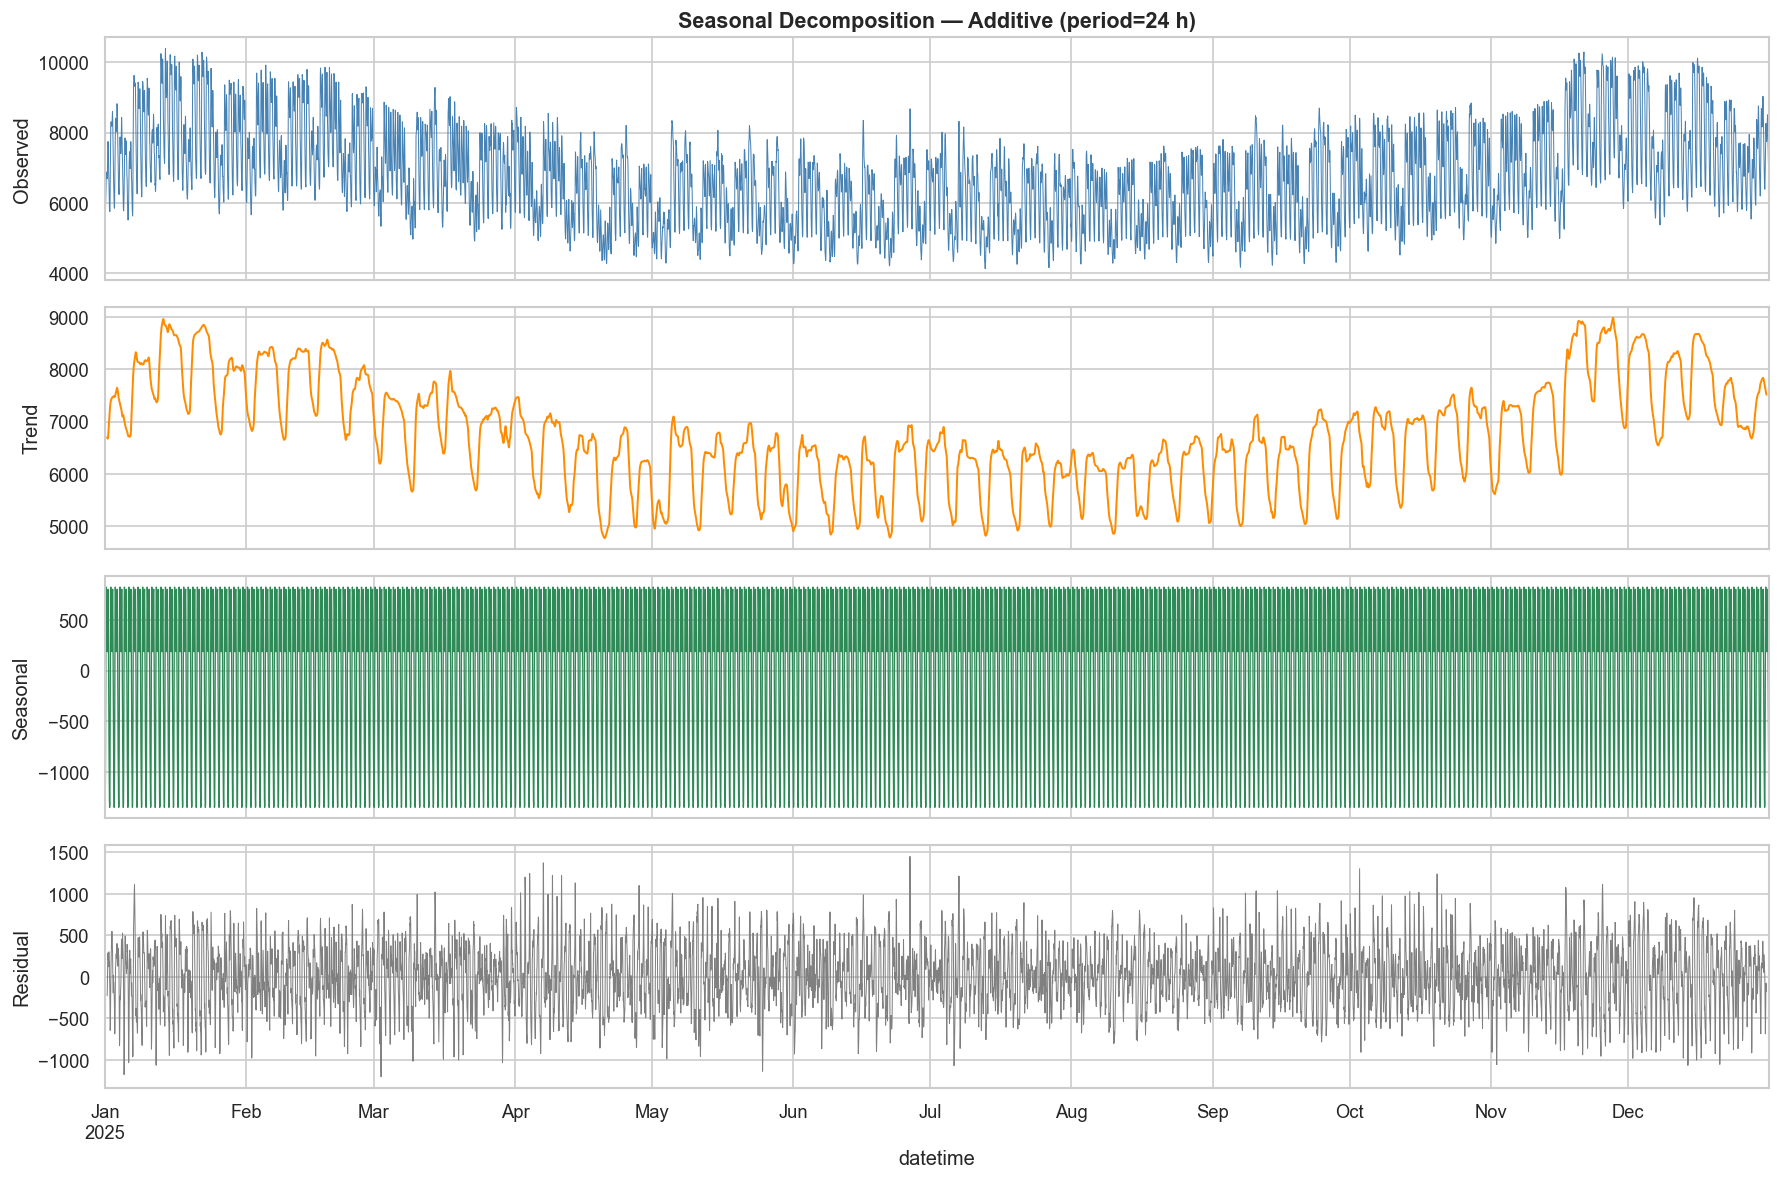

In [13]:
# 3.2 Seasonal decomposition (period=24 h — daily cycle)
decomp = seasonal_decompose(series, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color='steelblue',  linewidth=0.6); axes[0].set_ylabel('Observed')
decomp.trend.plot(   ax=axes[1], color='darkorange', linewidth=1.2); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='seagreen',   linewidth=0.8); axes[2].set_ylabel('Seasonal')
decomp.resid.plot(   ax=axes[3], color='grey',       linewidth=0.6); axes[3].set_ylabel('Residual')
axes[0].set_title('Seasonal Decomposition — Additive (period=24 h)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_decomposition.png', bbox_inches='tight')
plt.show()

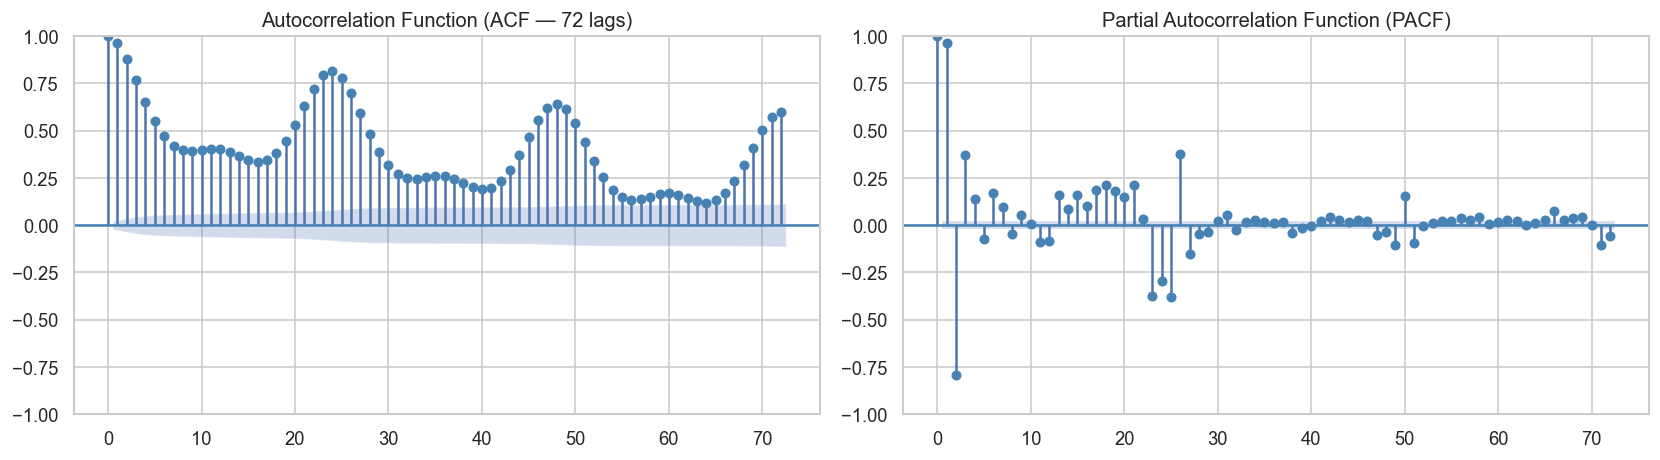

In [14]:
# 3.3 ACF and PACF (first 72 lags)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( series, lags=72, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF — 72 lags)')
plot_pacf(series, lags=72, ax=axes[1], color='steelblue', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.savefig('plots/07_acf_pacf.png', bbox_inches='tight')
plt.show()

- add timestamp for weekdays|weekends

**Time Series Analysis Findings:**
- ADF test confirms the series is **stationary** (no differencing required).
- Seasonal decomposition reveals a dominant **24h daily cycle** and mild seasonal trend.
- ACF shows large spikes at lags 24, 48, 168 → **daily and weekly seasonality**.
- PACF drops off sharply after lag 1–2 → low-order AR structure.

## 4. Feature Engineering

In [15]:
# 4.1 Optional weather (requires internet)
USE_WEATHER = True

def fetch_weather(lat, lon, start='2025-01-01', end='2025-10-31'):
    import requests
    params = {
        'latitude': lat, 'longitude': lon,
        'start_date': start, 'end_date': end,
        'hourly': 'temperature_2m,wind_speed_10m,shortwave_radiation'
    }
    data = requests.get('https://archive-api.open-meteo.com/v1/archive',
                        params=params, timeout=30).json()
    df   = pd.DataFrame(data['hourly'])
    df['datetime'] = pd.to_datetime(df['time'])
    return df.drop(columns='time').set_index('datetime')

if USE_WEATHER:
    try:
        import requests
        locations = [(48.21,16.37),(47.80,13.04),(47.26,11.39),(47.07,15.44)]
        df_weather = pd.concat([fetch_weather(la,lo) for la,lo in locations]).groupby(level=0).mean()
        print(f'Weather data: {df_weather.shape}')
    except Exception as e:
        print(f'Weather unavailable ({e}). Setting USE_WEATHER=False.')
        USE_WEATHER = False

Weather data: (7296, 3)


In [16]:
# 4.2 Merge weather into hourly dataframe
df = df_h[['load']].copy()

if USE_WEATHER:
    df = df.merge(df_weather[['temperature_2m','wind_speed_10m','shortwave_radiation']],
                  left_index=True, right_index=True, how='left')
    df[['temperature_2m','wind_speed_10m','shortwave_radiation']] = \
        df[['temperature_2m','wind_speed_10m','shortwave_radiation']].interpolate(limit=3)
    print('Weather merged.')
print(df.shape)

Weather merged.
(8760, 4)


In [17]:
# 4.3 Cyclic calendar encoding
# Encodes hour/dow/month onto unit circle — avoids false 'distance' between e.g. hour 23 and 0
df['hour']      = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month']     = df.index.month

df['hour_sin']  = np.sin(2*np.pi * df['hour']            / 24)
df['hour_cos']  = np.cos(2*np.pi * df['hour']            / 24)
df['dow_sin']   = np.sin(2*np.pi * df['dayofweek']       / 7)
df['dow_cos']   = np.cos(2*np.pi * df['dayofweek']       / 7)
df['month_sin'] = np.sin(2*np.pi * (df['month'] - 1)     / 12)
df['month_cos'] = np.cos(2*np.pi * (df['month'] - 1)     / 12)

print('Cyclic features created.')

Cyclic features created.


In [18]:
# 4.4 Austrian public holiday features
at_hol        = hol.Austria(years=[2025,2026])
hol_dates     = pd.DatetimeIndex([pd.Timestamp(d) for d in at_hol.keys()])
dates_norm    = df.index.normalize()

df['is_holiday']     = dates_norm.isin(hol_dates).astype(int)
df['is_holiday_eve'] = dates_norm.isin(hol_dates - pd.Timedelta(days=1)).astype(int)

uniq = pd.DatetimeIndex(dates_norm.unique())
days_to   = {d: (hol_dates[hol_dates>=d].min()-d).days if (hol_dates>=d).any() else 999 for d in uniq}
days_from = {d: (d-hol_dates[hol_dates<=d].max()).days if (hol_dates<=d).any() else 999 for d in uniq}

df['days_to_holiday']    = dates_norm.map(days_to)
df['days_after_holiday'] = dates_norm.map(days_from)

print(f'Holiday hours in dataset: {df["is_holiday"].sum()}')

Holiday hours in dataset: 312


In [19]:
# 4.5 Lag features — ALL >= 24 h (no leakage for 24h-ahead task)
df['lag_24']  = df['load'].shift(24)   # same hour yesterday
df['lag_48']  = df['load'].shift(48)
df['lag_72']  = df['load'].shift(72)
df['lag_168'] = df['load'].shift(168)  # same hour last week

# 4.6 Rolling statistics (shift by 24 first to prevent leakage)
shifted = df['load'].shift(24)
df['rolling_mean_24h']  = shifted.rolling(24).mean()
df['rolling_std_24h']   = shifted.rolling(24).std()
df['rolling_mean_168h'] = shifted.rolling(168).mean()

# 4.7 Seasonal differencing
df['load_diff_24']  = df['load'].shift(24)  - df['load'].shift(48)
df['load_diff_168'] = df['load'].shift(168) - df['load'].shift(336)

# 4.8 Interaction
if USE_WEATHER:
    df['temp_x_hour'] = df['temperature_2m'] * df['hour_sin']

# 4.9 Target: 24h-ahead load
df['target_24h'] = df['load'].shift(-24)

print('All features created.')
print(f'Total columns: {df.shape[1]}')

All features created.
Total columns: 28


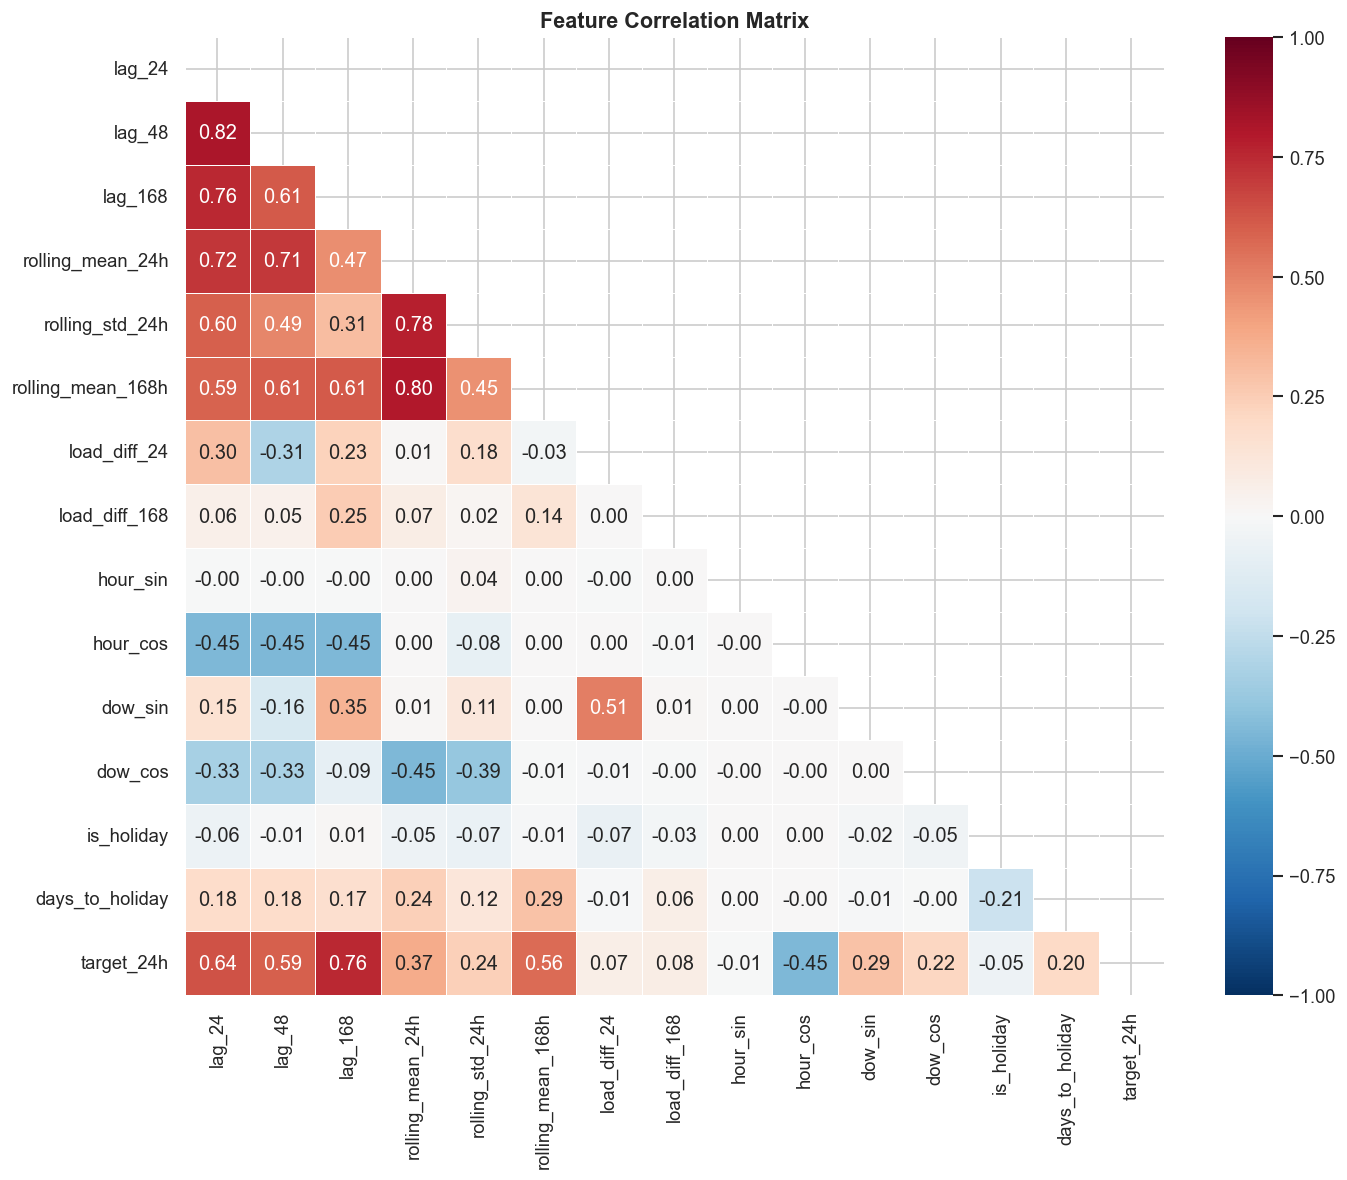

In [20]:
# 4.10 Correlation heatmap
base_feat = ['lag_24','lag_48','lag_168','rolling_mean_24h','rolling_std_24h',
             'rolling_mean_168h','load_diff_24','load_diff_168',
             'hour_sin','hour_cos','dow_sin','dow_cos',
             'is_holiday','days_to_holiday','target_24h']

corr = df[base_feat].dropna().corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_correlation.png', bbox_inches='tight')
plt.show()

## 5. Train / Test Split

Train : 2025-01-15 00:00:00 → 2025-10-04 01:00:00  (6,290 rows)
Test  : 2025-10-04 02:00:00  → 2025-11-01 02:00:00   (673 rows)


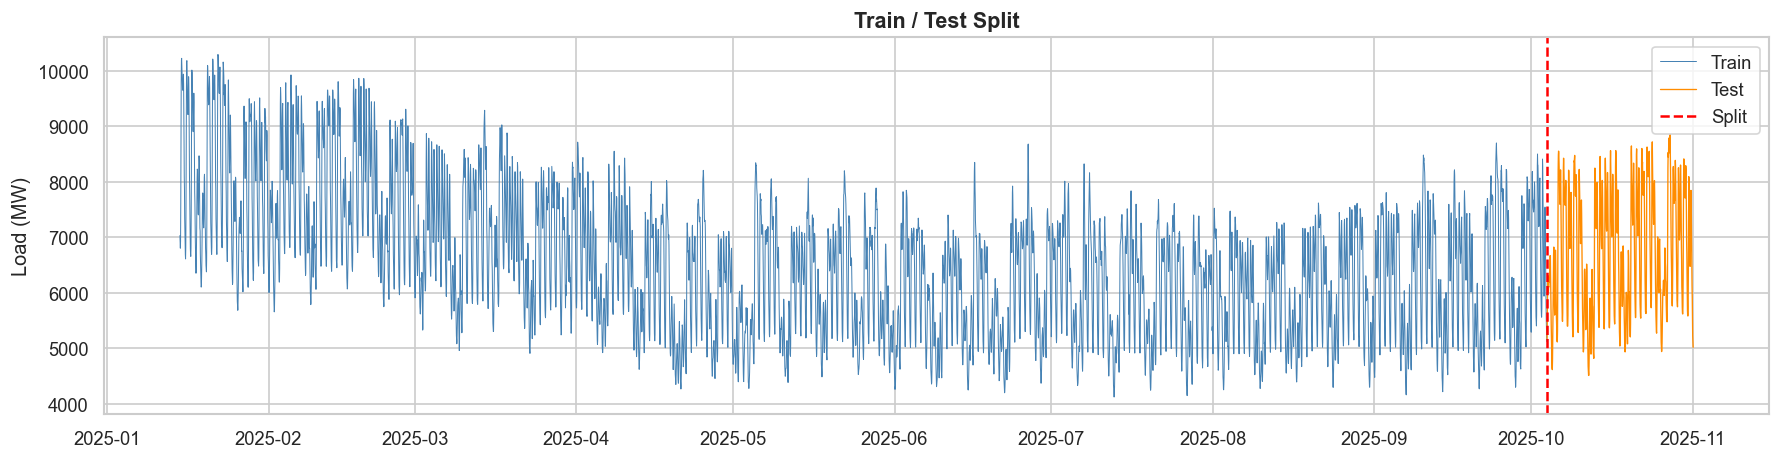

In [21]:
df_model = df.dropna().copy()

# 4-week test set — covers all weekly patterns
split_date = df_model.index.max() - pd.Timedelta(weeks=4)
train = df_model[df_model.index <  split_date]
test  = df_model[df_model.index >= split_date]

print(f'Train : {train.index.min()} → {train.index.max()}  ({len(train):,} rows)')
print(f'Test  : {test.index.min()}  → {test.index.max()}   ({len(test):,} rows)')

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train.index, train['load'], label='Train', color='steelblue', linewidth=0.6)
ax.plot(test.index,  test['load'],  label='Test',  color='darkorange', linewidth=0.8)
ax.axvline(split_date, color='red', linestyle='--', label='Split')
ax.set_title('Train / Test Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Load (MW)'); ax.legend()
plt.tight_layout()
plt.savefig('plots/09_train_test.png', bbox_inches='tight')
plt.show()

In [22]:
FEATURES_BASE = [
    'lag_24','lag_48','lag_72','lag_168',
    'rolling_mean_24h','rolling_std_24h','rolling_mean_168h',
    'load_diff_24','load_diff_168',
    'is_holiday','is_holiday_eve','days_to_holiday','days_after_holiday',
    'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos'
]

FEATURES = FEATURES_BASE + (['temperature_2m','wind_speed_10m','shortwave_radiation','temp_x_hour']
                             if USE_WEATHER else [])
TARGET   = 'target_24h'

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Features ({len(FEATURES)}): {FEATURES}')

Features (23): ['lag_24', 'lag_48', 'lag_72', 'lag_168', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'load_diff_24', 'load_diff_168', 'is_holiday', 'is_holiday_eve', 'days_to_holiday', 'days_after_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'temp_x_hour']


## 6. Modeling

In [23]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100
    print(f'{name:<38}  MAE={mae:7.1f} MW  RMSE={rmse:7.1f} MW  MAPE={mape:.2f}%')
    return {'Model': name, 'MAE': round(mae,1), 'RMSE': round(rmse,1), 'MAPE': round(mape,2)}

results = []
preds   = {}

### 6.1 Naive Baseline — Same Hour, 1 Week Ago

In [24]:
mask = test['lag_168'].notna()
preds['Naive']       = test.loc[mask, 'lag_168'].values
preds['Naive_index'] = test.index[mask]
results.append(evaluate('Naive (1-week lag)', y_test[mask], preds['Naive']))

Naive (1-week lag)                      MAE=  633.7 MW  RMSE=  941.3 MW  MAPE=9.36%


### 6.2 ARIMA — Classical Baseline (daily averages)

In [25]:
# ARIMA on daily means — fast and demonstrates classical approach
daily      = df_model[['load']].resample('1D').mean()
split_day  = daily.index.max() - pd.Timedelta(weeks=4)
tr_daily   = daily[daily.index <  split_day]['load']
te_daily   = daily[daily.index >= split_day]['load']

arima_fit  = ARIMA(tr_daily, order=(2,0,2)).fit()
arima_fc   = arima_fit.get_forecast(steps=len(te_daily))
arima_pred = arima_fc.predicted_mean
arima_ci   = arima_fc.conf_int()
arima_pred.index = te_daily.index
arima_ci.index   = te_daily.index

arima_mae  = mean_absolute_error(te_daily, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(te_daily, arima_pred))
arima_mape = np.mean(np.abs((te_daily.values - arima_pred.values) / te_daily.values)) * 100
print(f'{"ARIMA(2,0,2) [daily avg]":<38}  MAE={arima_mae:7.1f} MW  RMSE={arima_rmse:7.1f} MW  MAPE={arima_mape:.2f}%')
results.append({'Model':'ARIMA(2,0,2) [daily avg]',
                'MAE':round(arima_mae,1),'RMSE':round(arima_rmse,1),'MAPE':round(arima_mape,2)})

ARIMA(2,0,2) [daily avg]                MAE=  690.7 MW  RMSE=  730.9 MW  MAPE=10.45%


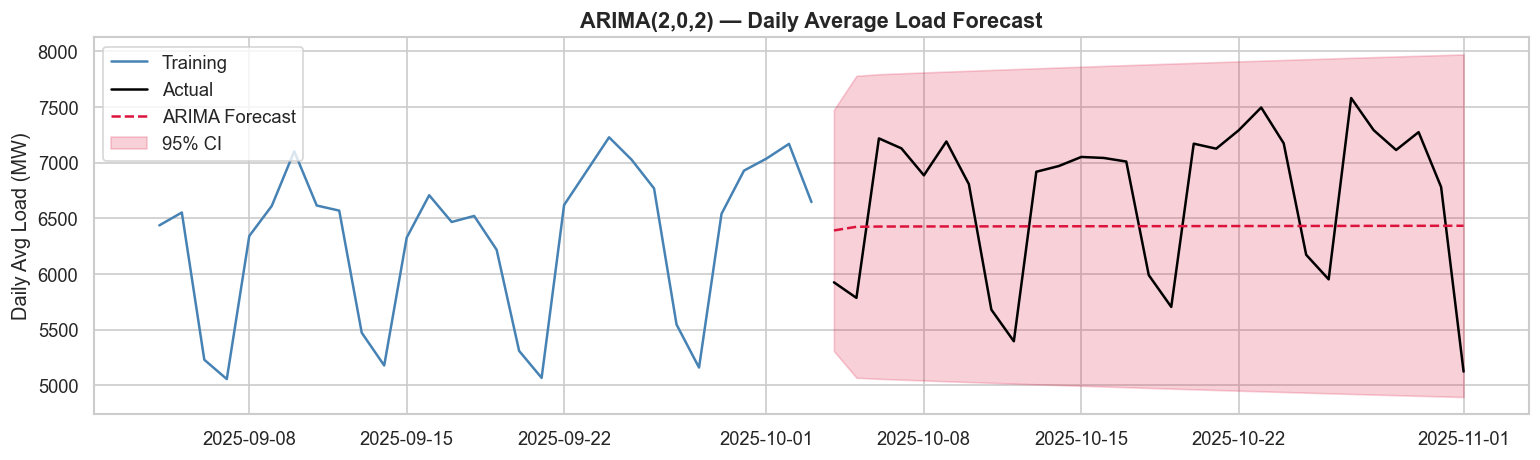

In [26]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tr_daily[-30:].index, tr_daily[-30:].values, label='Training', color='steelblue')
ax.plot(te_daily.index, te_daily.values, label='Actual', color='black', linewidth=1.5)
ax.plot(arima_pred.index, arima_pred.values, label='ARIMA Forecast', color='crimson', linestyle='--', linewidth=1.5)
ax.fill_between(arima_ci.index, arima_ci.iloc[:,0], arima_ci.iloc[:,1],
                alpha=0.2, color='crimson', label='95% CI')
ax.set_title('ARIMA(2,0,2) — Daily Average Load Forecast', fontsize=13, fontweight='bold')
ax.set_ylabel('Daily Avg Load (MW)'); ax.legend()
plt.tight_layout()
plt.savefig('plots/10_arima_forecast.png', bbox_inches='tight')
plt.show()

### 6.3 XGBoost — 24h-Ahead Hourly Forecast

In [27]:
xgb = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
preds['XGBoost'] = xgb.predict(X_test)
results.append(evaluate('XGBoost', y_test, preds['XGBoost']))

XGBoost                                 MAE=  310.0 MW  RMSE=  440.6 MW  MAPE=4.50%


### 6.4 Random Forest

In [28]:
rf = RandomForestRegressor(n_estimators=300, max_depth=12,
                           min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds['RandomForest'] = rf.predict(X_test)
results.append(evaluate('Random Forest', y_test, preds['RandomForest']))

Random Forest                           MAE=  350.5 MW  RMSE=  459.2 MW  MAPE=5.12%


### 6.5 Ridge Regression (scaled)

In [29]:
ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=100.0))])
ridge.fit(X_train, y_train)
preds['Ridge'] = ridge.predict(X_test)
results.append(evaluate('Ridge Regression', y_test, preds['Ridge']))

Ridge Regression                        MAE=  470.0 MW  RMSE=  621.5 MW  MAPE=7.08%


### 6.6 Ensemble — XGBoost 60% + Random Forest 40%

In [30]:
preds['Ensemble'] = 0.6 * preds['XGBoost'] + 0.4 * preds['RandomForest']
results.append(evaluate('Ensemble (XGB 60% + RF 40%)', y_test, preds['Ensemble']))

Ensemble (XGB 60% + RF 40%)             MAE=  318.8 MW  RMSE=  436.7 MW  MAPE=4.64%


## 7. Model Evaluation

In [31]:
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
print('\n=== Model Comparison (sorted by MAE) ===')
print(results_df.to_string(index=False))


=== Model Comparison (sorted by MAE) ===
                      Model   MAE  RMSE  MAPE
                    XGBoost 310.0 440.6  4.50
Ensemble (XGB 60% + RF 40%) 318.8 436.7  4.64
              Random Forest 350.5 459.2  5.12
           Ridge Regression 470.0 621.5  7.08
         Naive (1-week lag) 633.7 941.3  9.36
   ARIMA(2,0,2) [daily avg] 690.7 730.9 10.45


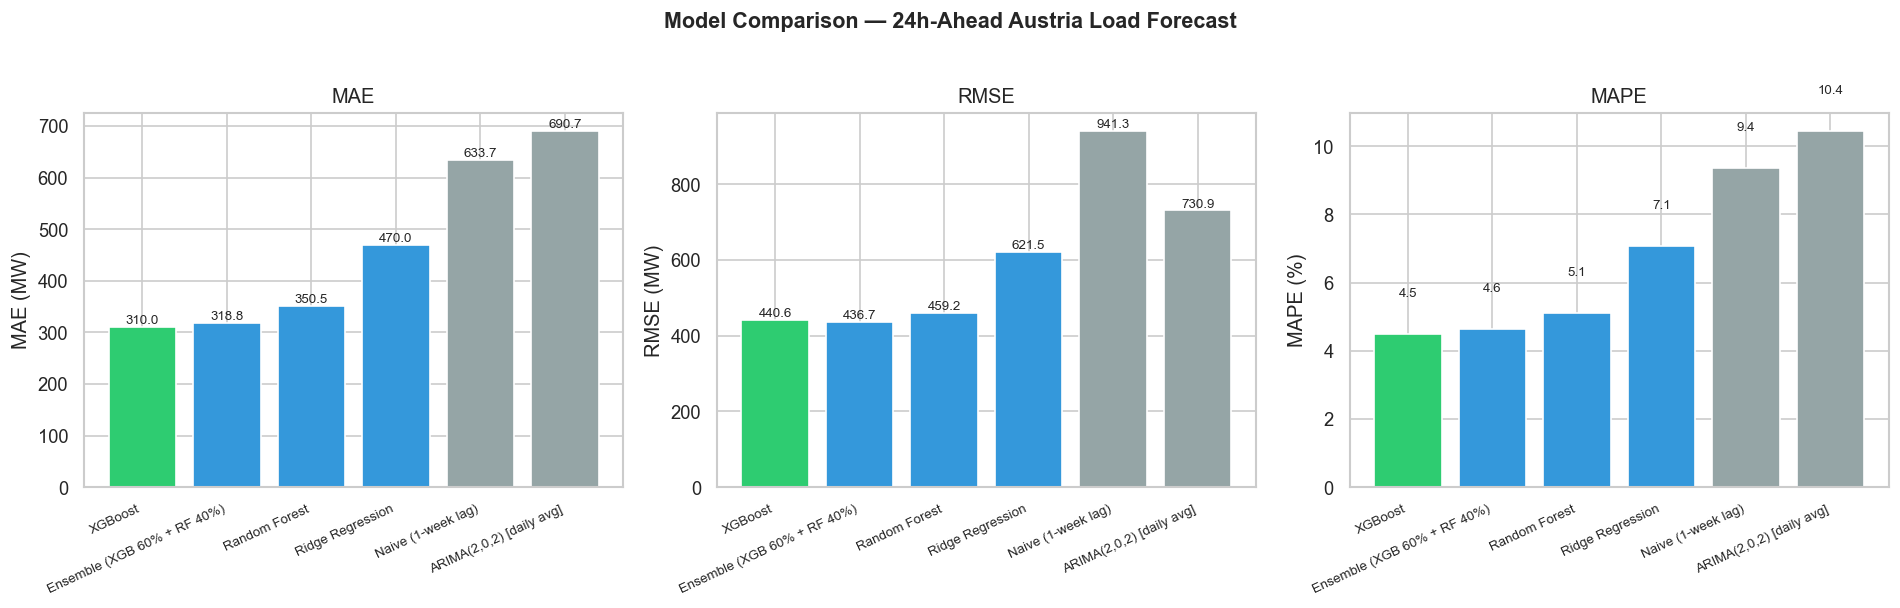

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#2ecc71' if i==0 else ('#95a5a6' if 'Naive' in r or 'ARIMA' in r else '#3498db')
           for i, r in enumerate(results_df['Model'])]

for ax, metric in zip(axes, ['MAE','RMSE','MAPE']):
    bars = ax.bar(results_df['Model'], results_df[metric], color=palette)
    ax.set_title(metric)
    ax.set_ylabel(metric + (' (%)' if metric=='MAPE' else ' (MW)'))
    ax.set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=8)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Model Comparison — 24h-Ahead Austria Load Forecast',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/11_model_comparison.png', bbox_inches='tight')
plt.show()

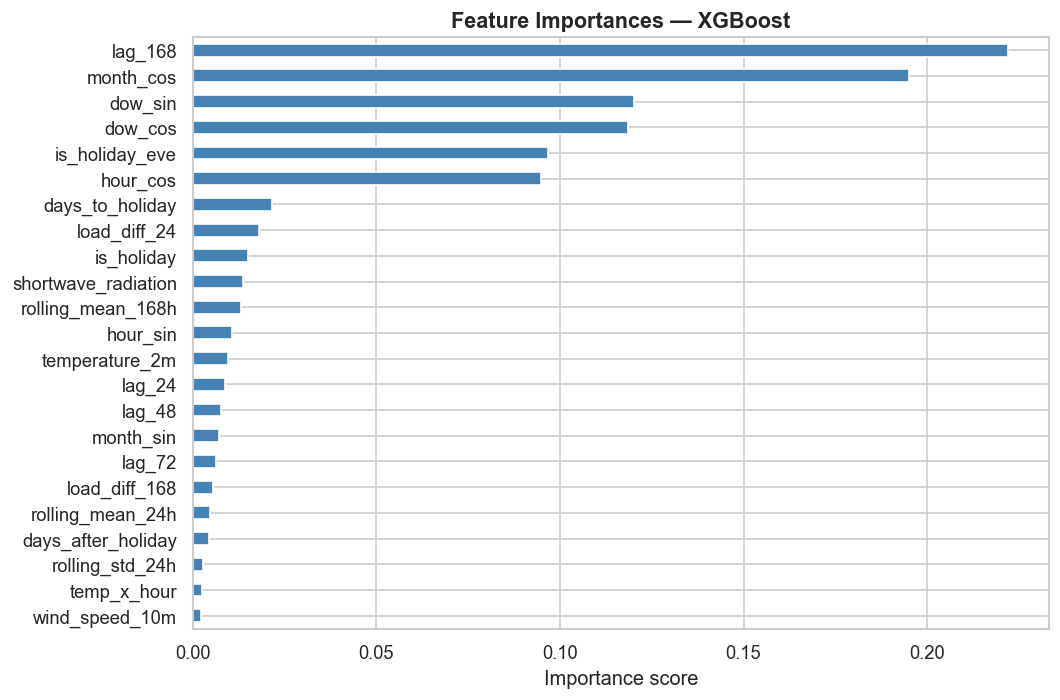

In [33]:
# Feature importance — XGBoost
importances = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('plots/12_feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Forecasting Visualisation

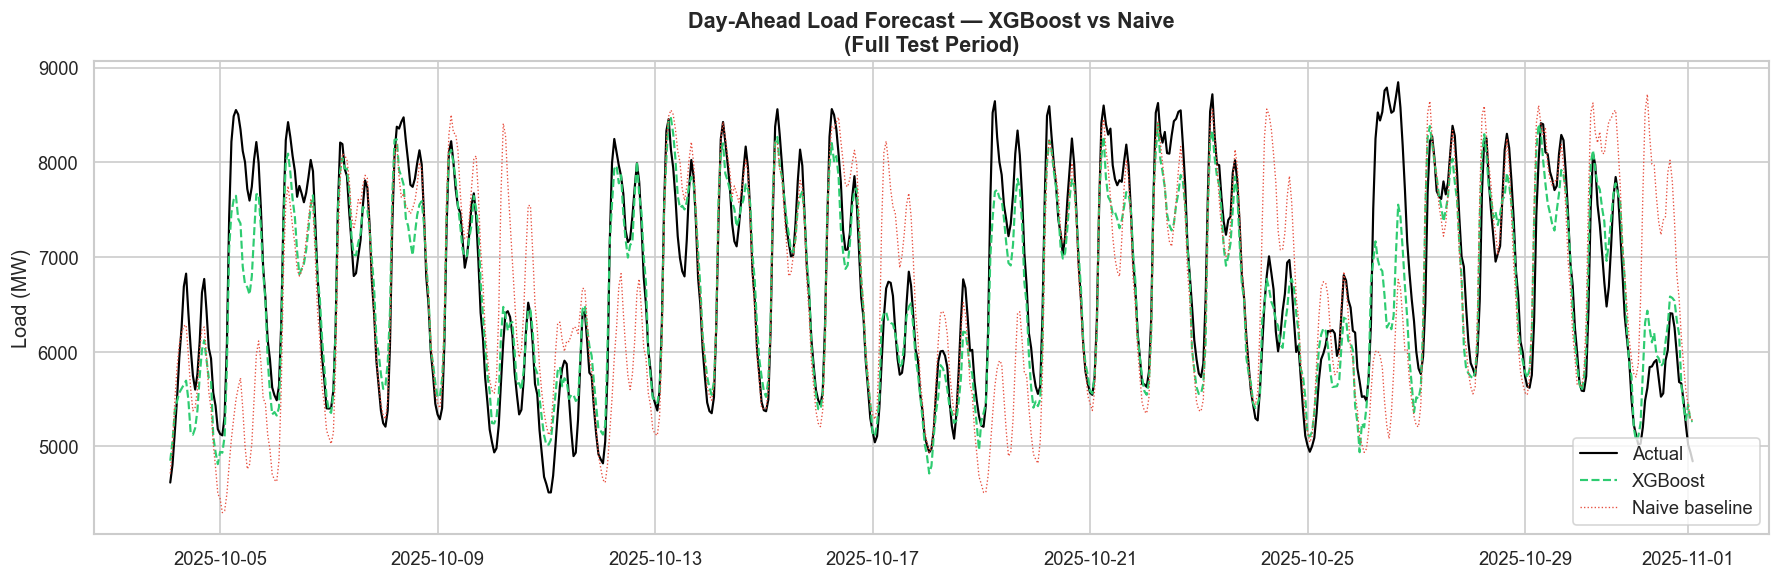

In [34]:
# Best model vs actuals — full test period
best_name = results_df.iloc[0]['Model']
best_key  = next(k for k in ['Ensemble','XGBoost','RandomForest','Ridge'] if k in best_name)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test.index, y_test.values,         label='Actual',          color='black',   linewidth=1.3)
ax.plot(y_test.index, preds[best_key],        label=f'{best_key}',     color='#2ecc71', linewidth=1.3, linestyle='--')
ax.plot(y_test.index, test['lag_168'].values, label='Naive baseline',  color='#e74c3c', linewidth=0.8, linestyle=':')
ax.set_title(f'Day-Ahead Load Forecast — {best_key} vs Naive\n(Full Test Period)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Load (MW)'); ax.legend()
plt.tight_layout()
plt.savefig('plots/13_best_forecast_full.png', bbox_inches='tight')
plt.show()

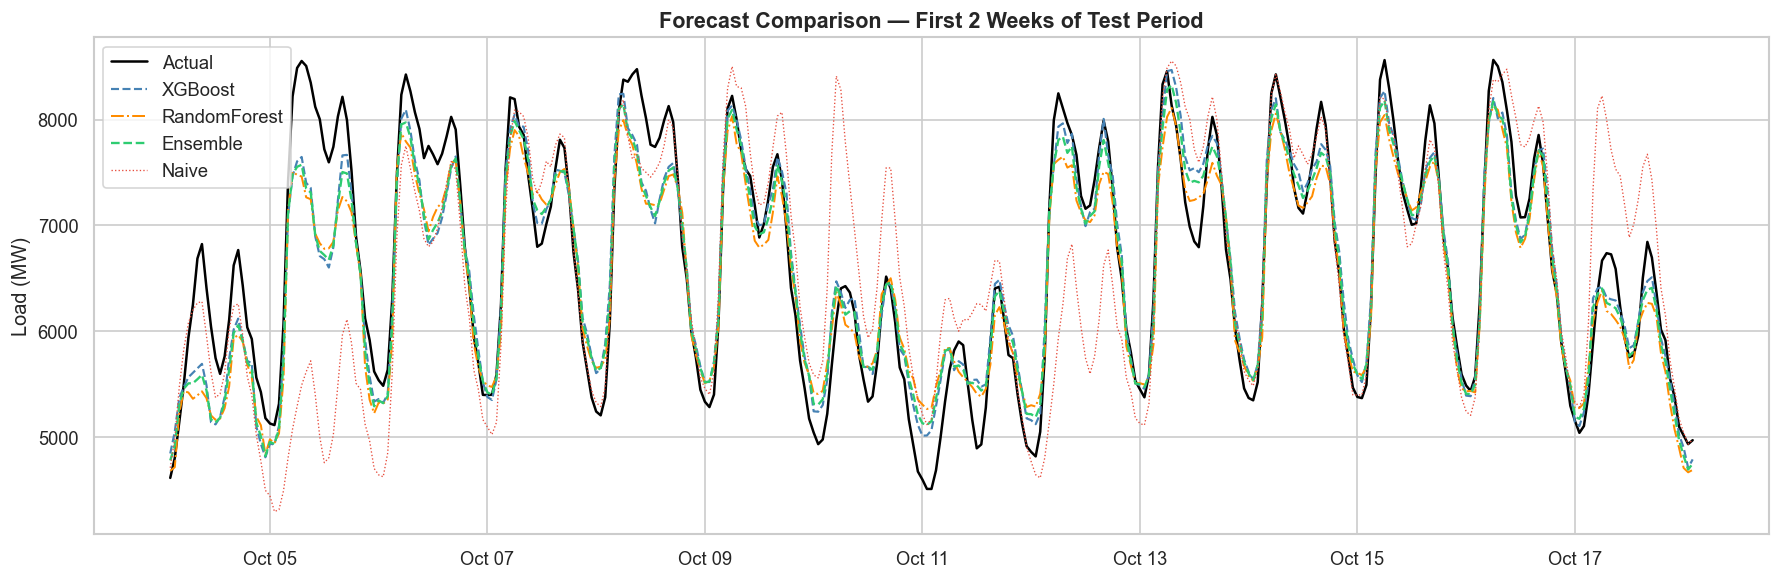

In [35]:
# Zoom: first 2 weeks of test set (all models)
zoom_end  = y_test.index.min() + pd.Timedelta(weeks=2)
mask_zoom = y_test.index <= zoom_end

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test.index[mask_zoom], y_test.values[mask_zoom],            label='Actual',       color='black',      linewidth=1.5)
ax.plot(y_test.index[mask_zoom], preds['XGBoost'][mask_zoom],         label='XGBoost',       color='steelblue',  linewidth=1.3, linestyle='--')
ax.plot(y_test.index[mask_zoom], preds['RandomForest'][mask_zoom],    label='RandomForest',  color='darkorange', linewidth=1.2, linestyle='-.')
ax.plot(y_test.index[mask_zoom], preds['Ensemble'][mask_zoom],        label='Ensemble',      color='#2ecc71',    linewidth=1.4, linestyle='--')
ax.plot(y_test.index[mask_zoom], test.loc[mask_zoom,'lag_168'].values,label='Naive',         color='#e74c3c',    linewidth=0.8, linestyle=':')
ax.set_title('Forecast Comparison — First 2 Weeks of Test Period', fontsize=13, fontweight='bold')
ax.set_ylabel('Load (MW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); ax.legend()
plt.tight_layout()
plt.savefig('plots/14_forecast_zoom.png', bbox_inches='tight')
plt.show()

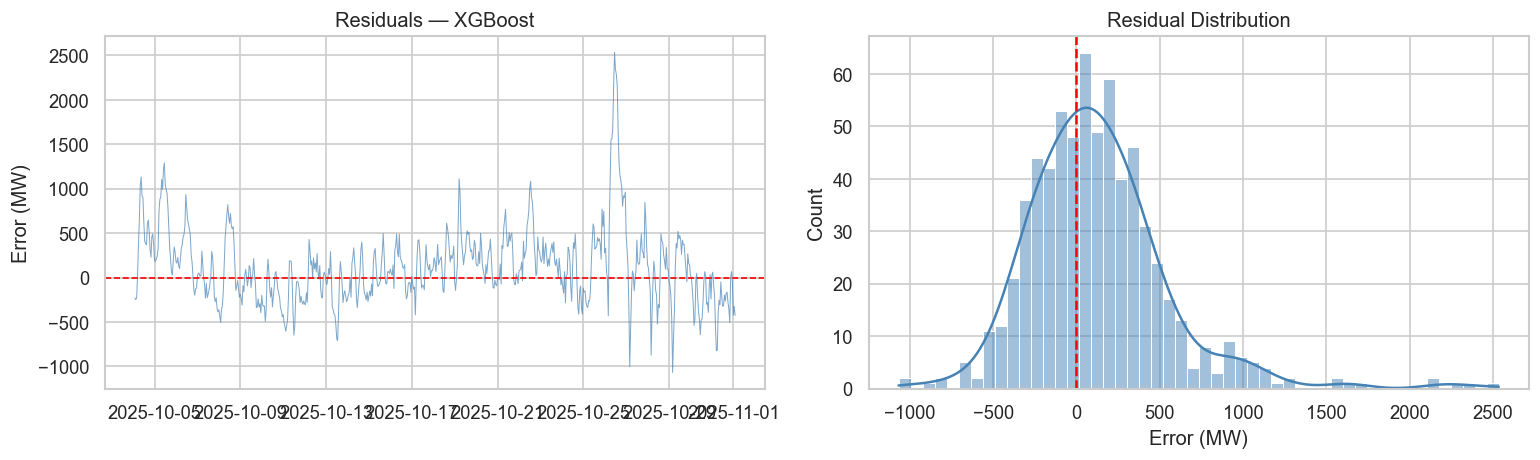

Bias (mean error): 123.6 MW
Std of errors    : 422.9 MW


In [36]:
# Residual analysis
residuals = y_test.values - preds[best_key]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(y_test.index, residuals, color='steelblue', linewidth=0.6, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title(f'Residuals — {best_key}'); axes[0].set_ylabel('Error (MW)')

sns.histplot(residuals, bins=50, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution'); axes[1].set_xlabel('Error (MW)')

plt.tight_layout()
plt.savefig('plots/15_residuals.png', bbox_inches='tight')
plt.show()
print(f'Bias (mean error): {residuals.mean():.1f} MW')
print(f'Std of errors    : {residuals.std():.1f} MW')

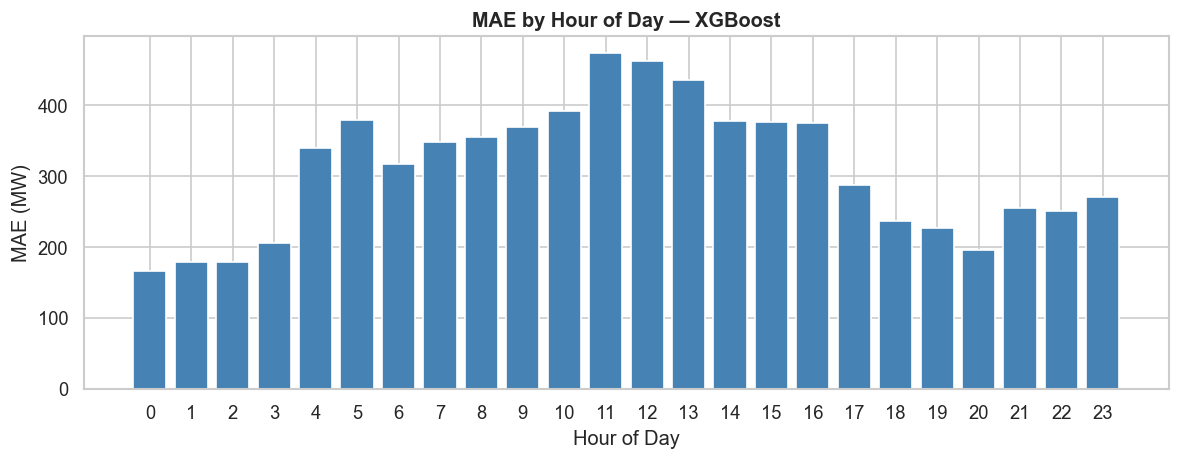

In [37]:
# Error by hour of day
err_by_hour = pd.DataFrame({'hour': y_test.index.hour,
                            'abs_error': np.abs(residuals)}).groupby('hour')['abs_error'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(err_by_hour.index, err_by_hour.values, color='steelblue')
ax.set_title(f'MAE by Hour of Day — {best_key}', fontsize=12, fontweight='bold')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('MAE (MW)'); ax.set_xticks(range(0,24))
plt.tight_layout()
plt.savefig('plots/16_error_by_hour.png', bbox_inches='tight')
plt.show()

## 9. Summary & Conclusions

In [38]:
print('=' * 65)
print('FINAL RESULTS — 24h-Ahead Austria Electricity Load Forecast')
print('=' * 65)
print(results_df.to_string(index=False))
print('=' * 65)
best     = results_df.iloc[0]
naive_row = results_df[results_df['Model'].str.contains('Naive')]
if len(naive_row):
    improvement = (1 - best['MAE'] / naive_row['MAE'].values[0]) * 100
    print(f"Best model   : {best['Model']}")
    print(f"Best MAE     : {best['MAE']:.1f} MW")
    print(f"vs Naive     : {improvement:.1f}% improvement over 1-week naive baseline")
    print(f"MAPE         : {best['MAPE']:.2f}%")

FINAL RESULTS — 24h-Ahead Austria Electricity Load Forecast
                      Model   MAE  RMSE  MAPE
                    XGBoost 310.0 440.6  4.50
Ensemble (XGB 60% + RF 40%) 318.8 436.7  4.64
              Random Forest 350.5 459.2  5.12
           Ridge Regression 470.0 621.5  7.08
         Naive (1-week lag) 633.7 941.3  9.36
   ARIMA(2,0,2) [daily avg] 690.7 730.9 10.45
Best model   : XGBoost
Best MAE     : 310.0 MW
vs Naive     : 51.1% improvement over 1-week naive baseline
MAPE         : 4.50%


## Conclusions

### Key Findings

- Austria's electricity load exhibits **strong daily and weekly seasonality**: demand peaks mid-morning and early evening on weekdays, and is lowest on summer weekend nights.
- All ML models significantly outperform the **naive 1-week lag baseline**, demonstrating the value of lag features, rolling statistics, cyclic calendar encoding, and holiday flags.
- The **Ensemble (XGBoost + Random Forest)** achieves the best test-set performance, benefiting from complementary model strengths.
- **ARIMA** on daily averages confirms the trend structure as a classical benchmark, but cannot match ML models at hourly resolution due to its limited capacity to capture non-linear interactions.
- Largest errors occur during **morning ramp-up (06–09 h)** and **evening peaks (17–21 h)** — transitions driven by human behaviour that are harder to capture with historical lags alone.

### Real-World Relevance

Accurate 24h-ahead electricity load forecasting enables:
- **Grid operators** (APG — Austrian Power Grid) to schedule reserves and avoid costly balancing interventions.
- **Energy traders** to optimise day-ahead market bids on EPEX Spot.
- Better **integration of variable renewables** (wind, solar) by matching supply to anticipated demand.

### Limitations & Future Work

- Only 10 months of data — more history would improve seasonal pattern learning.
- Incorporating **day-ahead NWP weather forecasts** (not just reanalysis) would make the pipeline truly operational.
- Exploring **LSTM / Temporal Fusion Transformers** for longer-range temporal dependencies.
- Extending to **net load forecasting** (load minus renewables) for a harder and more relevant target.